In [245]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

Part 1

In [246]:
def LCG(a, c, M, x0, n):
    x = np.zeros(n)
    x[0] = x0 % M
    for i in range (1,n):
        x[i] = (a*x[i-1] + c) % M
    return x

In [247]:
x = LCG(5, 1, 16, 3, 10000)/16
# print(x)

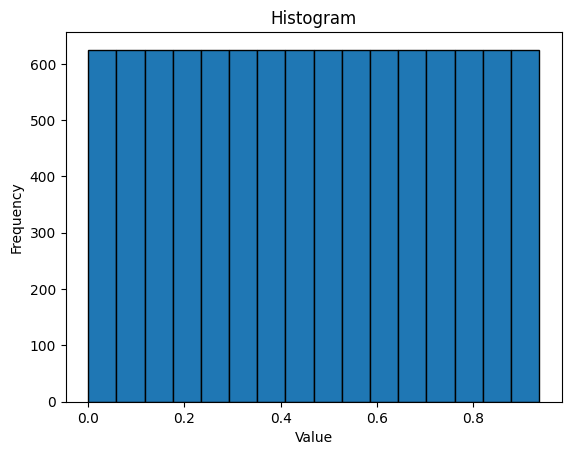

In [248]:
plt.hist(x, bins=16, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show() 

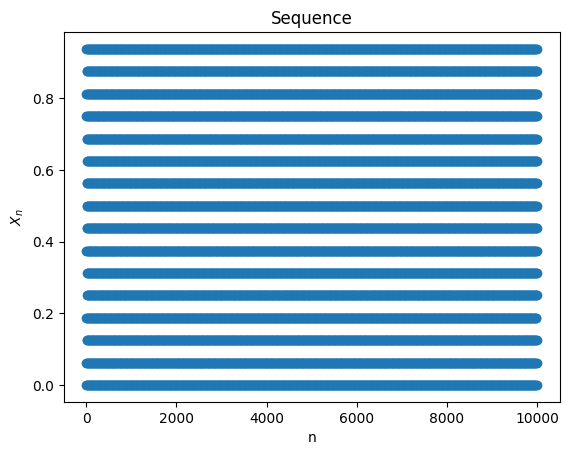

In [249]:
plt.scatter(np.arange(len(x)), x)
plt.title('Sequence')
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.show()

Text(0, 0.5, '$x_{n+1}$')

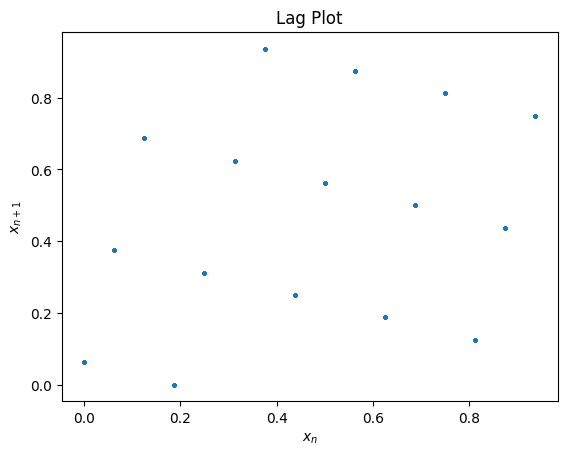

In [ ]:
plt.plot(x[:-1], x[1:], ".", markersize=3)
plt.title("Lag Plot")
plt.xlabel("$x_n$")
plt.ylabel("$x_{n+1}$")

In [251]:
def chi2_test(counts,N):
    n = len(counts)

    T = 0
    for i in range(n):
        n_expected = N/n
        n_observed = counts[i]
        T += (n_observed-n_expected)**2 / n_expected

    p_val = 1-ss.chi2.cdf(T,df=n-1)
    return p_val

N = 10000
counts, _ = np.histogram(x, bins=16)
chi2_test(counts,N)

np.float64(1.0)

In [252]:
data = x
F = lambda x: np.clip(x, 0, 1)  # uniform distribution

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    p = np.arange(len(data)) / (len(data) - 1)    # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    return D

D = smirnov(x, F)
print(D)

0.0625


In [253]:
def run_test_1(x):
    m = np.median(x)
    n1 = np.sum(x > m)
    n2 = np.sum(x <= m)

    # loc = 2 * n1*n2 / (n1+n2) + 1
    # scale = 2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)^2 * (n1+n2-1))
    # t = np.linspace(loc-4*scale, loc+4*scale, 1000)
    # normal = ss.norm.pdf(t, loc, scale)
    # plt.plot(t, normal)

    mu_T = 2 * n1*n2 / (n1+n2) + 1 # Mean, or Expected number of runs
    sig_T = np.sqrt(2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)**2 * (n1+n2-1))) # Variance

    s = (x > m) # Number of runs above the median

    T = 1 + np.sum(s[1:] != s[:-1]) # Compare adjacent elements to obtain T
    print('Total number of runs: T =', T)

    Z = (T - mu_T) / sig_T # Measure how far we are from what we expect
    print('Comparison with the theory: Z =', Z)
    print(f"pval: {2*(1-ss.norm.cdf(abs(Z)))}")


    return(T,Z)

In [254]:
a = [129, 5, 1103515245, 1664525]
c = [26461, 1, 12345, 1013904223]
M = [64499, 16, 2**31, 2**32]
N = [10_000, 10_000, 10_000, 10_000]
seed = [30,30,30,30]

In [255]:
for i in range(4):
    x = LCG(a[i], c[i], M[i], seed[i], N[i])/M[i]
    counts, _ = np.histogram(x, bins=16)

    print("Tests:")
    print(f"Chisq-test: {chi2_test(counts,N[i])}")
    print("\nRun test:")
    run_test_1(x)
    print(f"\nSmirnov test: {smirnov(x, F)}")

Tests:
Chisq-test: 0.9317305338198677

Run test:
Total number of runs: T = 4958
Comparison with the theory: Z = -0.8600430075263439
pval: 0.3897653356239932

Smirnov test: 0.008830252472835642
Tests:
Chisq-test: 1.0

Run test:
Total number of runs: T = 3751
Comparison with the theory: Z = -25.001250218789068
pval: 0.0

Smirnov test: 0.0625
Tests:
Chisq-test: 0.5362334783778987

Run test:
Total number of runs: T = 5030
Comparison with the theory: Z = 0.5800290050759064
pval: 0.5618950581019284

Smirnov test: 0.006693007767420989
Tests:
Chisq-test: 0.5047680733419597

Run test:
Total number of runs: T = 5050
Comparison with the theory: Z = 0.9800490085765314
pval: 0.327061927672712

Smirnov test: 0.01615895061475292


In [256]:
# np.random.seed(0)
# x = np.random.uniform(size=10000)
# print(x)

# T, Z = run_test_1(x)
# D = smirnov(x,F)
# print(D)

Part 2

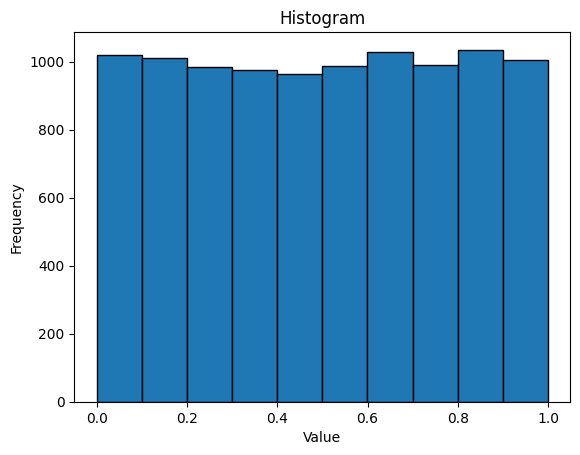

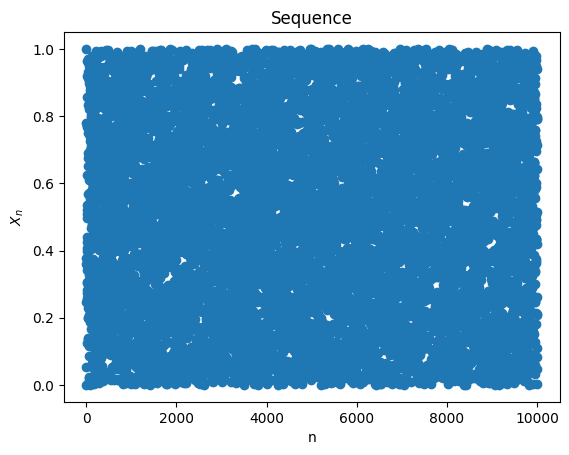

Tests:
Chisq-test: 0.8510483670629825

Run test
Total number of runs: T = 4912
Comparison with the theory: Z = -1.7800890155777815
pval: 0.0750613939575997

Smirnov test: 0.007984710126879624


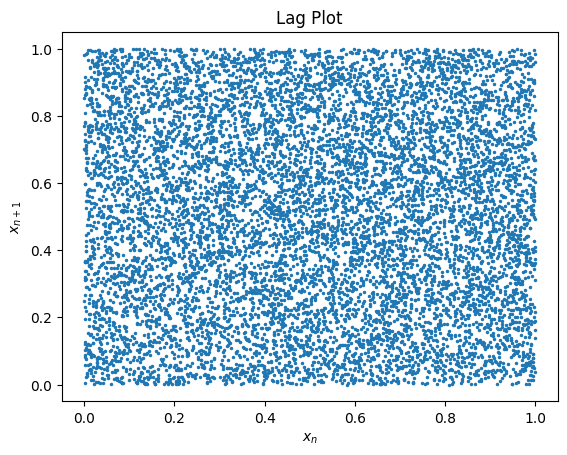

In [264]:
np.random.seed(30)
x2 = np.random.uniform(size=10_000)
counts2, _ = np.histogram(x2, bins=10)

plt.hist(x2, bins=10, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

plt.scatter(np.arange(len(x)), x)
plt.title('Sequence')
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.show()

plt.plot(x[:-1], x[1:], ".", markersize=3)
plt.title("Lag Plot")
plt.xlabel("$x_n$")
plt.ylabel("$x_{n+1}$")


print("Tests:")
print(f"Chisq-test: {chi2_test(counts2,10_000)}")
print("\nRun test")
run_test_1(x2)
print(f"\nSmirnov test: {smirnov(x2, F)}")